In [ ]:
# Fig. 1| Subregion parcellation of human hippocampus by gene expression pattern. 

## Fig1b-脑区注释画图

In [3]:
HS22_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS22/HS22.area_m.line.rds')
HS33_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS33/HS33.area_m.line.rds')
HS34_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS34/HS34.area_m.line.rds')
HS8_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS8/HS8.area_m.line.rds')
HS26_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS26/HS26.area_m.line.rds')
HS29_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS29/HS29.area_m.line.rds')
HS36_line = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/01.rds_line/04.bin100_bayes36_adjust/HS36/HS36.area_m.line.rds')

In [4]:
seuobj = readRDS('/data/users/liuyuyang/online/03.result/01.bin100/00.02.7samples/bin100.7samples.FAS_SLRM_split.CA1_Deep_Sup.merge.240722.rds')
seuobj$area = seuobj$area_m
scRNAlist = SplitObject(seuobj,split.by = "sample")

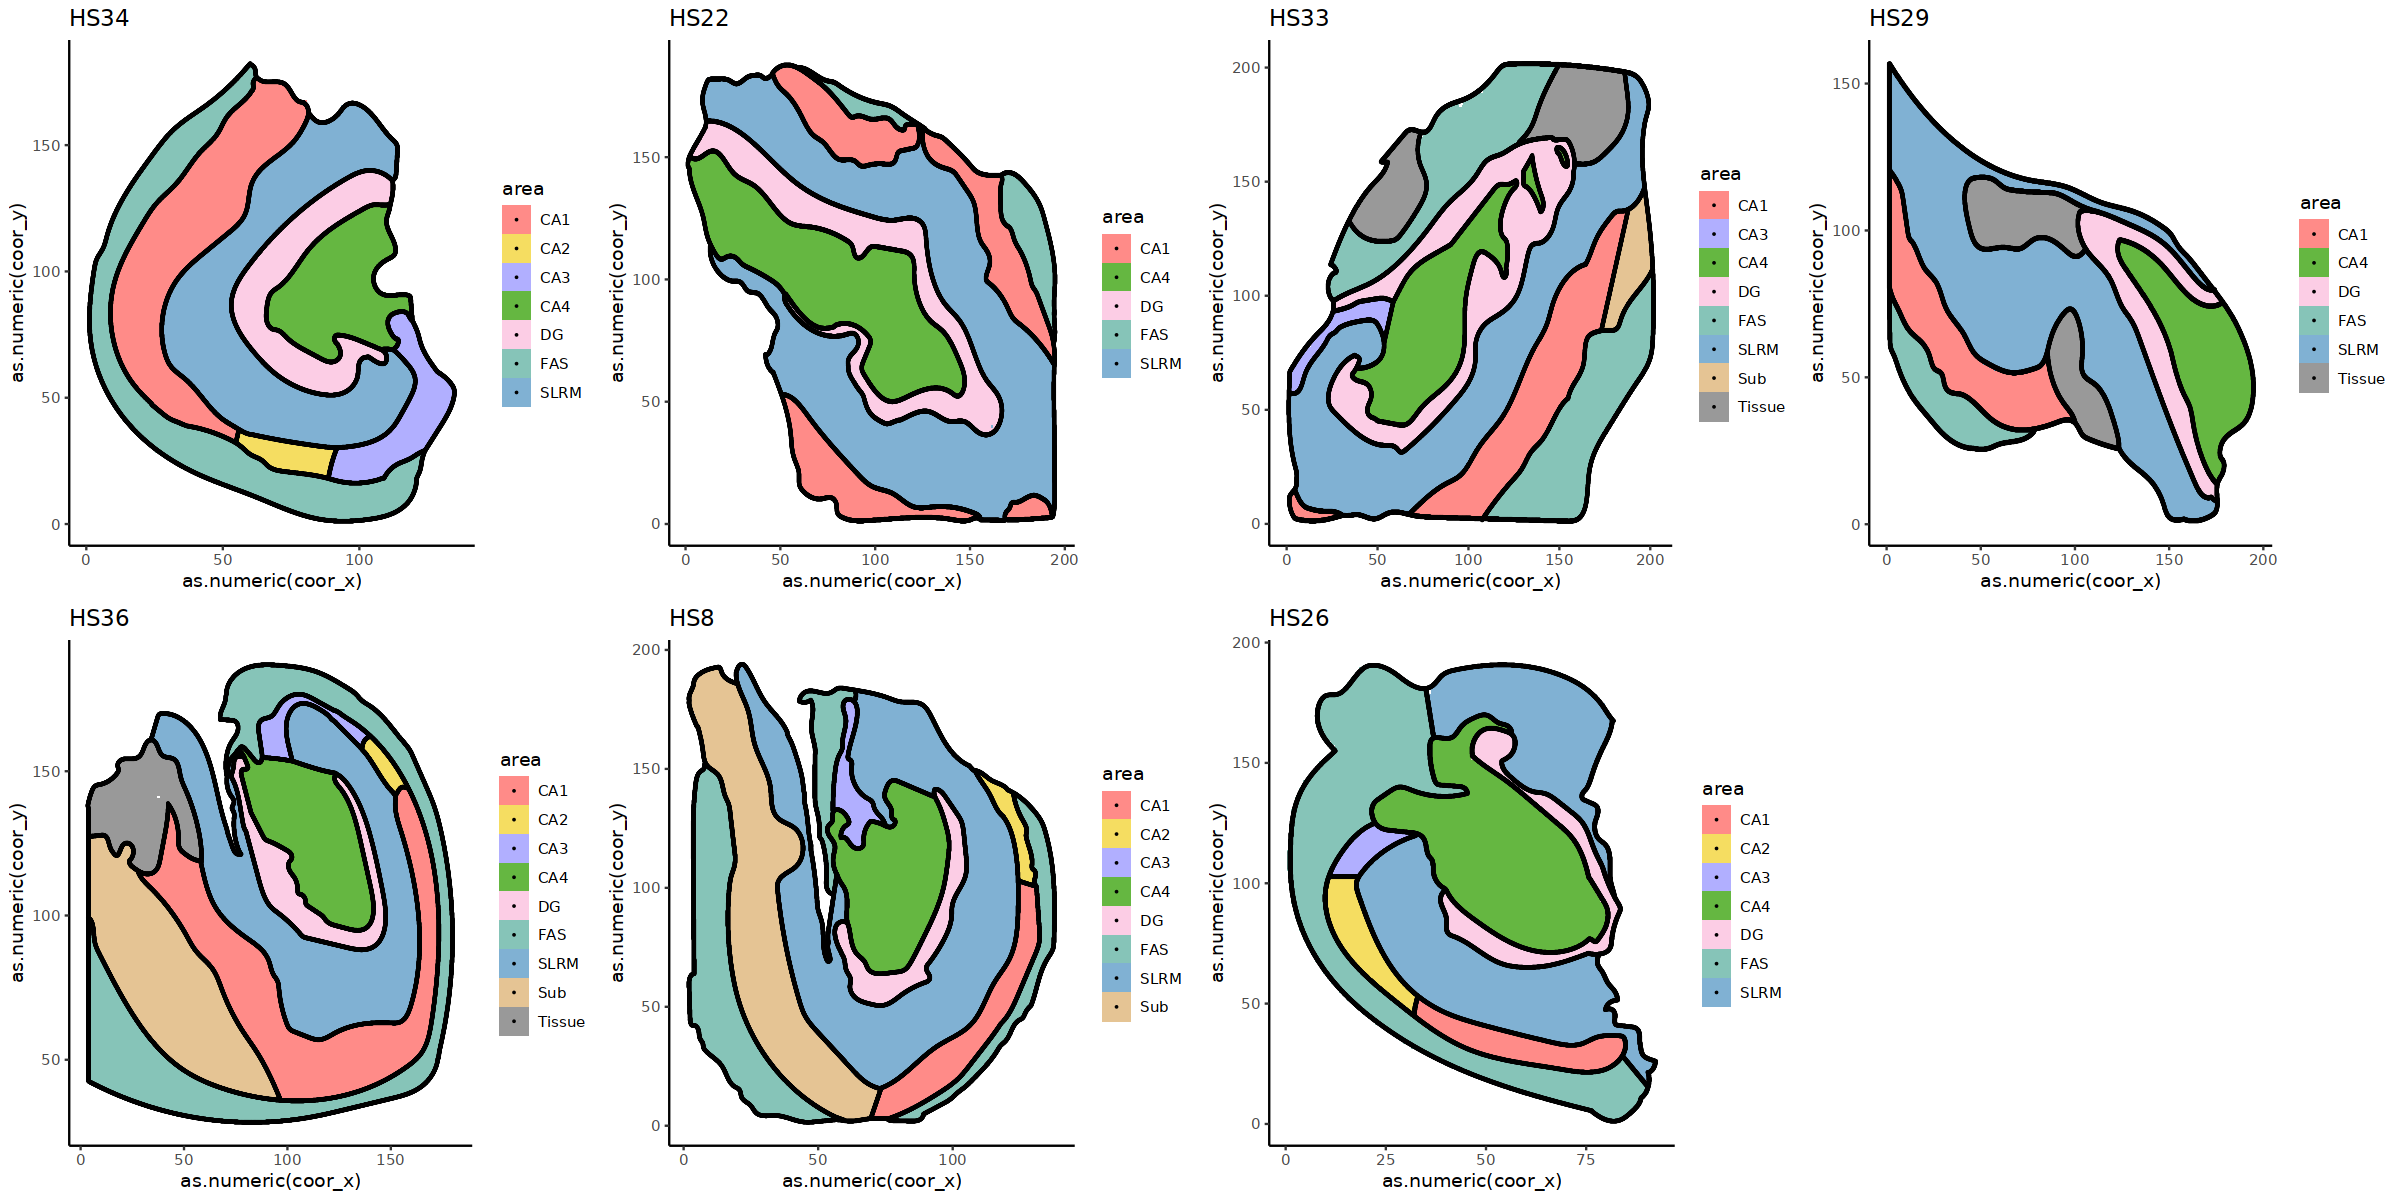

In [7]:
p = list()   

p[['HS34']] = ggplot(scRNAlist[['HS34']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS34']]$area)] ) +
    labs(title = 'HS34')+
    geom_point(data = HS34_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    
    
p[['HS22']] = ggplot(scRNAlist[['HS22']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS22']]$area)] ) +
    labs(title = 'HS22')+
    geom_point(data = HS22_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    
    
p[['HS33']] =ggplot(scRNAlist[['HS33']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS33']]$area)] ) +
    labs(title = 'HS33')+
    geom_point(data = HS33_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    

p[['HS29']] = ggplot(scRNAlist[['HS29']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS29']]$area)] ) +
    labs(title = 'HS29')+
    geom_point(data = HS29_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    

p[['HS36']] = ggplot(scRNAlist[['HS36']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS36']]$area)] ) +
    labs(title = 'HS36')+
    geom_point(data = HS36_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")


p[['HS8']] = ggplot(scRNAlist[['HS8']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS8']]$area)] ) +
    labs(title = 'HS8')+
    geom_point(data = HS8_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    
    
p[['HS26']] = ggplot(scRNAlist[['HS26']]@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= area))+  geom_tile() + theme_classic()+
    scale_fill_manual(values = cols[unique(scRNAlist[['HS26']]$area)] ) +
    labs(title = 'HS26')+
    geom_point(data = HS26_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    

library(cowplot)
p_all=plot_grid(plotlist = p,ncol = 4 )
options(repr.plot.width=20, repr.plot.height=10)
p_all

## Fig1c-与10X数据PCA

In [65]:
plat_deg = readRDS('/data/work/03.result/01.bin100/02_integrated/00.ADstereo_vs_10X.area_merge.allgenes.rds')
dim(plat_deg)
plat_deg$max.pct = apply(plat_deg[,c("pct.1","pct.2")],1,max)
plat_deg$up.down = "No_Sig"

logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
plat_deg$up.down[which(plat_deg$max.pct> pct.filter & plat_deg$p_val_adj<adjPvalFilter & plat_deg$avg_log2FC>logFCfilter)] = "up"
plat_deg$up.down[which(plat_deg$max.pct> pct.filter & plat_deg$p_val_adj<adjPvalFilter & plat_deg$avg_log2FC< -logFCfilter)] = "down"
plat_deg = plat_deg[which(plat_deg$up.down %in% c('up','down') ),]
plat_deg = plat_deg[which(plat_deg$up.down %in% 'up' ),]
dim(plat_deg)

[1] 5314    8

[1] 606  10

In [66]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

deg1 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/01.HS-vs-10XHealth.area_split.allgenes.rds')
de = deg1
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg1 = de

deg2 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/01.nonHS-vs-10XHealth.area_split.allgenes.rds')
de = deg2
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg2 = de


deg3 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02.HS-vs-nonHS.area_split.allgenes.rds')
de = deg3
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg3 = de


In [67]:
table(deg1$compare)
table(deg2$compare)
table(deg3$compare)


HS-vs-Health 
       23292 


Normal-vs-Health 
           18857 


HS-vs-Normal 
        6730 

In [68]:
deg1$compare = gsub('Normal','nonHS',deg1$compare)
deg2$compare = gsub('Normal','nonHS',deg2$compare)
deg3$compare = gsub('Normal','nonHS',deg3$compare)

print(unique(deg1$compare) )
table(deg1$up.down,deg1$cluster)

print(unique(deg2$compare) )
table(deg2$up.down,deg2$cluster)

print(unique(deg3$compare) )
table(deg3$up.down,deg3$cluster)

df1 = data.frame(table(deg1$up.down,deg1$cluster))
df1$compare = unique(deg1$compare)
df2 = data.frame(table(deg2$up.down,deg2$cluster))
df2$compare = unique(deg2$compare)
df3 = data.frame(table(deg3$up.down,deg3$cluster))
df3$compare = unique(deg3$compare)


[1] "HS-vs-Health"


      
        CA1  CA2  CA3  CA4   DG  FAS SLRM  Sub
  down  467  199  621  739  554  182  104   30
  up   2596 2611 2459 2184 2439 2218 2583 3306

[1] "nonHS-vs-Health"


      
        CA1  CA2  CA3  CA4   DG  FAS SLRM  Sub
  down  134  156  184  236  408  150   29   30
  up   2199 2099 1852 1811 1899 1996 2206 3468

[1] "HS-vs-nonHS"


      
       CA1 CA2 CA3 CA4  DG FAS SLRM Sub
  down 781 864 977 697 196 212  289 160
  up   620 142 312 508 339 278  275  80

In [69]:
df_all = rbind(df1,df2)
df_all = rbind(df_all,df3)
df_all$compare_area = paste0(df_all$compare,'_',df_all$Var2)

In [70]:
deg_all = rbind(deg1,deg2)
deg_all = rbind(deg_all,deg3)
deg_all$compare_area = paste0(deg_all$compare,'_',deg_all$cluster)
deg_all[1,]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down,compare_area
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
TTTY14,0,0.5341404,0.189,0.018,0,TTTY14,CA1,HS-vs-Health,0.189,up,HS-vs-Health_CA1


In [71]:
common_genes = deg_all %>% group_by(compare_area) %>% top_n(20,avg_log2FC)
common_genes = unique(common_genes$gene)
length(common_genes)

[1] 107

In [11]:
###### PCA

In [13]:
visium = readRDS('/data/work/03.result/04_public_spatial/Visium.20chips.area_anno.250525.rds')
visium$platform= '10X'
visium$sample = visium$chip

counts=visium@assays$RNA@counts
meta=visium@meta.data
visium = CreateSeuratObject(counts,
                             assay = "RNA",
                             meta.data = meta)
# seu_new = NormalizeData(seu_new)

In [14]:
stereo = readRDS('/data/work/03.result/01.bin100/01_lines/bin.12chips.merge.250526.rds')
stereo$platform = 'stereo'
stereo$nCount_RNA = stereo$nCount_Spatial
stereo$nFeature_RNA = stereo$nFeature_Spatial

In [ ]:
stereo$cells = row.names(stereo@meta.data)
stereo@meta.data = stereo@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','sample','area','platform','cells')]

visium$cells = row.names(visium@meta.data)
visium@meta.data = visium@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','sample','area','platform','cells')]

In [ ]:
seu_sub = merge(stereo,visium)
counts=seu_sub@assays$RNA@counts
counts = counts[intersect(row.names(stereo@assays$RNA@counts),row.names(visium@assays$RNA@counts) ) ,]
dim(counts)
meta=seu_sub@meta.data
seu_new = CreateSeuratObject(counts,
                             assay = "RNA",
                             meta.data = meta)

seu_new$chip = seu_new$sample
seu_new@meta.data = seu_new@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','chip','area','platform','cells')]


[1]  35147 305113

In [72]:
# ########### 合并后scale
# # # ####### counts重新创建rds
# length(common_genes)
# alldata = seu_new
# alldata = CreateSeuratObject(alldata@assays$RNA@counts,
#                                    meta.data = alldata@meta.data)
# alldata = NormalizeData(alldata)
# alldata <- FindVariableFeatures(alldata, selection.method = "vst",nfeatures = 3000) # Adjust nfeatures as needed
# alldata = ScaleData(alldata)

alldata = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/01_bin.stereo_visium.intersect_gene.af_scale.rds')

In [73]:
alldata@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,coor_y,coor_x,percent.mt,sample,area,platform,cells,person,group,sex,age
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
AAACAACGAATAGTTC-1_1,SeuratProject,113,90,17991,24903,15.9292,GSM8226199_V12F14-051_C1,FAS,10X,NA,GSM8226199,Health,F,48.2


In [74]:
alldata$chip = alldata$person
alldata$chip[which(alldata$chip=='HS42')] = alldata$sample[which(alldata$chip=='HS42')]

In [75]:
meta_all = readRDS('/data/work/02.file/file.01.03.stereo_10X.sample_info.rds')  #/data/users/liuyuyang/online/02.file/file.01.03.stereo_10X.sample_info.rds
# meta_all

In [76]:
meta_all[which(meta_all$sample == 'HS42_C04589F1'),'person'] = 'HS42C'
meta_all[which(meta_all$sample == 'HS42_Y00859A6'),'person'] = 'HS42Y'

In [77]:
# seu_new$group = meta_all$disease[match(seu_new$person,meta_all$person)]
# seu_new$sex = meta_all$sex[match(seu_new$person,meta_all$person)]
# seu_new$age = meta_all$age[match(seu_new$person,meta_all$person)]

In [78]:
exp_data_c = AverageExpression(alldata, group.by = 'sample',verbose  = TRUE)

In [79]:
length(common_genes)
length(intersect(common_genes,row.names(exp_data_c$RNA) ))

[1] 107

[1] 99

In [80]:
exp_data1 = exp_data_c$RNA  #readRDS('/data/work/08_Figure/00_Data/PCA_BIN100_alldata_chipID.rds') 
common_genes = intersect(common_genes,row.names(exp_data_c$RNA) )
exp_data1 = exp_data1[common_genes,]
# head(exp_data1,2)
metadata = alldata@meta.data

library(matrixStats)
dim(exp_data1)
# Remove genes with zero variance
row_vars <- rowVars(exp_data1)
exp_data1 <- exp_data1[row_vars > 0, ]
print(dim(exp_data1))  # 应显示 (基因数, 样本数)


[1] 99 32

Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”


[1] 99 32


In [81]:
meta_all$disease = gsub('_.*$','',meta_all$disease)
meta_all$disease = gsub('Normal','nonHS',meta_all$disease)
table(meta_all$disease )


   FCD Health     HS  nonHS 
     2      9      9      6 

In [82]:
table(meta_all$disease,meta_all$person )

        
         FCD10 FCD23 FCD31 GSM8226199 GSM8226201 GSM8226202 GSM8226203
  FCD        1     0     1          0          0          0          0
  Health     0     0     0          1          1          1          1
  HS         0     0     0          0          0          0          0
  nonHS      0     1     0          0          0          0          0
        
         GSM8226204 GSM8226205 GSM8226206 GSM8226207 GSM8226208 HS22 HS26 HS27
  FCD             0          0          0          0          0    0    0    0
  Health          1          1          1          1          1    0    0    0
  HS              0          0          0          0          0    0    1    0
  nonHS           0          0          0          0          0    1    0    1
        
         HS29 HS33 HS34 HS36 HS39 HS42C HS42Y HS43 HS45 HS50 HS8
  FCD       0    0    0    0    0     0     0    0    0    0   0
  Health    0    0    0    0    0     0     0    0    0    0   0
  HS        0    0    0    1

[1] 32  3

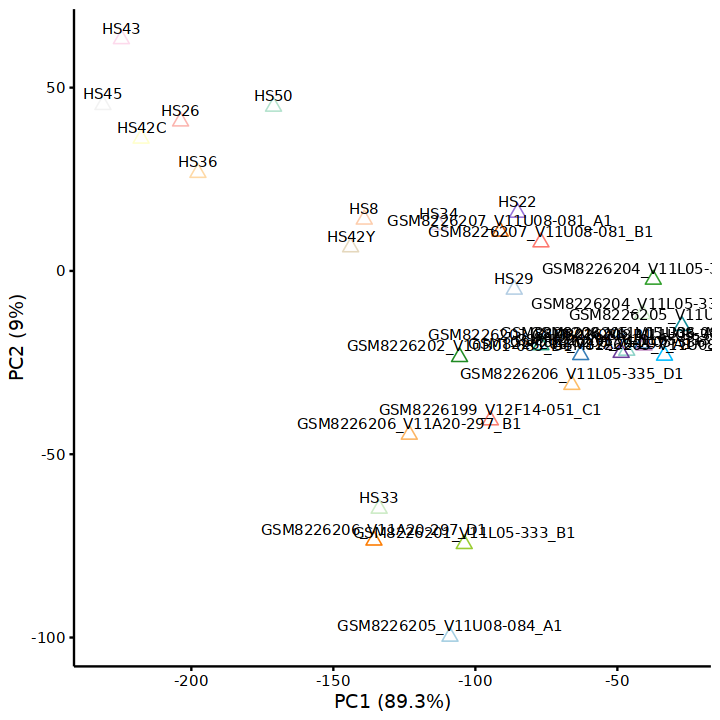

In [83]:
# table(metadata$age)
# table(alldata$group)

# Proceed with PCA
pca <- prcomp(t(exp_data1), scale = FALSE, center = FALSE)
# pca <- prcomp(t(exp_data1), scale = TRUE, center = TRUE) #基因1.

pca_data <- data.frame(PC1=pca$x[,1], PC2=pca$x[,2],type=colnames(exp_data1))
library(ggplot2)

dim(pca_data)
pca_data$chip = gsub('_.*$','',row.names(pca_data) )
pca_data$disease = meta_all$disease[match( pca_data$chip ,meta_all$person)]
pca_data$sex = meta_all$sex[match( pca_data$chip ,meta_all$person)]
pca_data$age = meta_all$age[match( pca_data$chip ,meta_all$person)]

# Create the plot
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = type, shape = type)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = rownames(pca_data)), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Set plot dimensions
options(repr.plot.width = 6, repr.plot.height = 6)

# Display the plot
p1

In [84]:
unique(pca_data$disease)
pca_data$disease = factor(pca_data$disease,levels = c('HS','Health','nonHS') )

[1] "Health" "nonHS"  "HS"

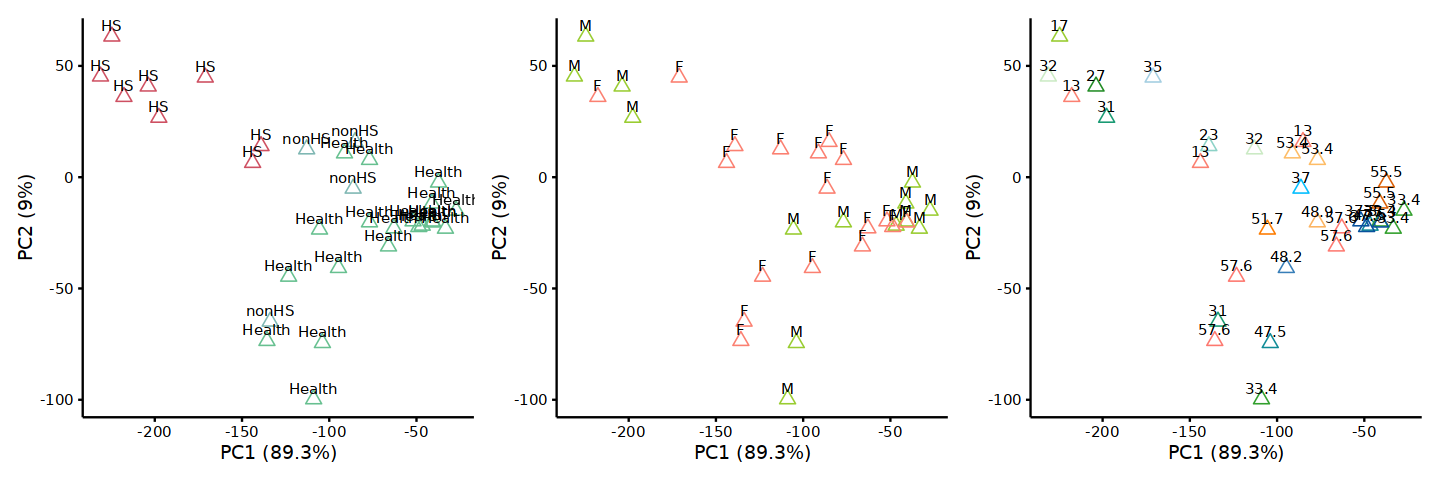

In [85]:
# Create the plot
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = disease, shape = disease)) +
  geom_point(size = 3) +
  scale_color_manual(values = rev(col1) ) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$disease ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Create the plot
p2 = ggplot(pca_data, aes(x = PC1, y = PC2, color = sex, shape = sex)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$sex ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Create the plot
pca_data$age = as.character(pca_data$age)
p3 = ggplot(pca_data, aes(x = PC1, y = PC2, color = age, shape = age)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black") #,legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$age ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')
# Set plot dimensions
options(repr.plot.width = 12, repr.plot.height = 4)

# Display the plot
p1+p2+p3

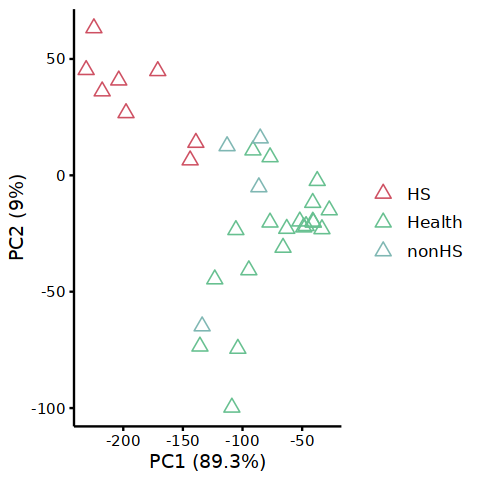

In [86]:
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = disease, shape = disease)) +
  geom_point(size = 3) +
  scale_color_manual(values = rev(col1) ) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black") #,legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = ""))
options(repr.plot.width = 4, repr.plot.height = 4)
p1


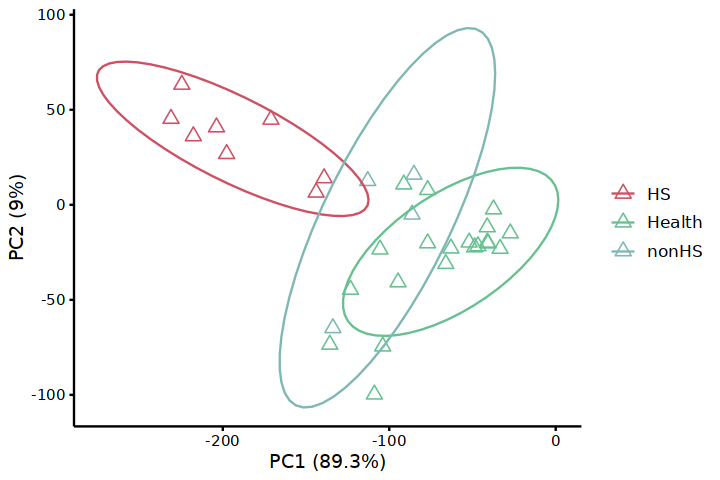

In [87]:
options(repr.plot.width = 6)
pp1 = p1+stat_ellipse(level = 0.9)
pp1

## Fig1d-与stereo公共数据PCA

In [37]:
plat_deg = readRDS('/data/work/03.result/01.bin100/02_integrated/00.ADstereo_vs_10X.area_merge.allgenes.rds')
dim(plat_deg)
plat_deg$max.pct = apply(plat_deg[,c("pct.1","pct.2")],1,max)
plat_deg$up.down = "No_Sig"

logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
plat_deg$up.down[which(plat_deg$max.pct> pct.filter & plat_deg$p_val_adj<adjPvalFilter & plat_deg$avg_log2FC>logFCfilter)] = "up"
plat_deg$up.down[which(plat_deg$max.pct> pct.filter & plat_deg$p_val_adj<adjPvalFilter & plat_deg$avg_log2FC< -logFCfilter)] = "down"
plat_deg = plat_deg[which(plat_deg$up.down %in% c('up','down') ),]
plat_deg = plat_deg[which(plat_deg$up.down %in% 'up' ),]
dim(plat_deg)

[1] 5314    8

[1] 606  10

In [38]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

deg1 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02.HS-vs-ADHealthy.area_split.allgenes.rds')
de = deg1
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg1 = de

deg2 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02.nonHS-vs-ADHealthy.area_split.allgenes.rds')
de = deg2
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg2 = de


deg3 = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02.HS-vs-nonHS.area_split.allgenes.rds')
de = deg3
de = de[-which(de$gene %in% plat_deg$gene),]
de$max.pct = apply(de[,c("pct.1","pct.2")],1,max)
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
de = de[which(de$up.down %in% c('up','down') ),]
deg3 = de


In [39]:
table(deg1$compare)
table(deg2$compare)
table(deg3$compare)


HS-vs-Normal 
       11218 


Normal-vs-nonHS 
           5293 


HS-vs-Normal 
        6730 

In [40]:
deg1$compare = gsub('Normal','nonHS',deg1$compare)
deg2$compare = gsub('Normal','nonHS',deg2$compare)
deg3$compare = gsub('Normal','nonHS',deg3$compare)

print(unique(deg1$compare) )
table(deg1$up.down,deg1$cluster)

print(unique(deg2$compare) )
table(deg2$up.down,deg2$cluster)

print(unique(deg3$compare) )
table(deg3$up.down,deg3$cluster)

df1 = data.frame(table(deg1$up.down,deg1$cluster))
df1$compare = unique(deg1$compare)
df2 = data.frame(table(deg2$up.down,deg2$cluster))
df2$compare = unique(deg2$compare)
df3 = data.frame(table(deg3$up.down,deg3$cluster))
df3$compare = unique(deg3$compare)


[1] "HS-vs-nonHS"


      
        CA1  CA2  CA3  CA4   DG  FAS SLRM  Sub
  down 1262  864 1175 1315  624  549  835  368
  up    719  564  764  825  517  238  405  194

[1] "nonHS-vs-nonHS"


      
       CA1 CA2 CA3 CA4  DG FAS SLRM Sub
  down 347 146 132 492 410 438  437 320
  up   212 557 380 399 365 272  150 236

[1] "HS-vs-nonHS"


      
       CA1 CA2 CA3 CA4  DG FAS SLRM Sub
  down 781 864 977 697 196 212  289 160
  up   620 142 312 508 339 278  275  80

In [41]:
df_all = rbind(df1,df2)
df_all = rbind(df_all,df3)
df_all$compare_area = paste0(df_all$compare,'_',df_all$Var2)

In [42]:
deg_all = rbind(deg1,deg2)
deg_all = rbind(deg_all,deg3)
deg_all$compare_area = paste0(deg_all$compare,'_',deg_all$cluster)
deg_all[1,]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down,compare_area
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
MT-TD,0,0.3105224,0.279,0.14,0,MT-TD,CA1,HS-vs-nonHS,0.279,up,HS-vs-nonHS_CA1


In [43]:
common_genes = deg_all %>% group_by(compare_area) %>% top_n(20,avg_log2FC)
common_genes = unique(common_genes$gene)
length(common_genes)

[1] 110

In [11]:
###### PCA

In [13]:
visium = readRDS('/data/work/03.result/04_public_spatial/Visium.20chips.area_anno.250525.rds')
visium$platform= '10X'
visium$sample = visium$chip

counts=visium@assays$RNA@counts
meta=visium@meta.data
visium = CreateSeuratObject(counts,
                             assay = "RNA",
                             meta.data = meta)
# seu_new = NormalizeData(seu_new)

In [ ]:
stereo = readRDS('/data/work/03.result/01.bin100/01_lines/bin.12chips.merge.250526.rds')
stereo$platform = 'stereo'
stereo$nCount_RNA = stereo$nCount_Spatial
stereo$nFeature_RNA = stereo$nFeature_Spatial


stereo$cells = row.names(stereo@meta.data)
stereo@meta.data = stereo@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','sample','area','platform','cells')]

visium$cells = row.names(visium@meta.data)
visium@meta.data = visium@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','sample','area','platform','cells')]


seu_sub = merge(stereo,visium)
counts=seu_sub@assays$RNA@counts
counts = counts[intersect(row.names(stereo@assays$RNA@counts),row.names(visium@assays$RNA@counts) ) ,]
dim(counts)
meta=seu_sub@meta.data
seu_new = CreateSeuratObject(counts,
                             assay = "RNA",
                             meta.data = meta)
seu_new$chip = seu_new$sample
seu_new@meta.data = seu_new@meta.data[,c('orig.ident','nCount_RNA','nFeature_RNA','coor_y','coor_x','percent.mt','chip','area','platform','cells')]


In [74]:
seu_new = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02_bin100.ADcon.epi.merge.rds')

In [75]:
seu_new@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,coor_y,coor_x,percent.mt,sample,area,platform,cells,person,group
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357,Con1.1,2588,640,611,0,NA,Con1.1,FAS,stereo,NA,Con1.1,Normal


In [76]:
alldata = seu_new
alldata = CreateSeuratObject(alldata@assays$RNA@counts,
                                   meta.data = alldata@meta.data)
alldata = NormalizeData(alldata)
alldata <- FindVariableFeatures(alldata, selection.method = "vst",nfeatures = 3000) # Adjust nfeatures as needed
alldata = ScaleData(alldata)

Centering and scaling data matrix



In [77]:
date()

[1] "Thu Aug 28 15:42:18 2025"

In [78]:
saveRDS(alldata,'/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02_bin100.ADcon.epi.af_scale.rds')

In [79]:
date()

[1] "Thu Aug 28 16:03:57 2025"

In [44]:
meta_all = readRDS('/data/work/02.file/file.01.03.stereo_10X.sample_info.rds')  #/data/users/liuyuyang/online/02.file/file.01.03.stereo_10X.sample_info.rds
meta_all[which(meta_all$sample == 'HS42_C04589F1'),'person'] = 'HS42C'
meta_all[which(meta_all$sample == 'HS42_Y00859A6'),'person'] = 'HS42Y'

In [45]:
alldata = readRDS('/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo/02_bin100.ADcon.epi.af_scale.rds')

In [46]:
alldata@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,coor_y,coor_x,percent.mt,sample,area,platform,cells,person,group
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357,Con1.1,2588,640,611,0,NA,Con1.1,FAS,stereo,NA,Con1.1,Normal


In [47]:
alldata$group = gsub('_.*$','',alldata$group)
table(alldata$group)


    HS  nonHS Normal 
 94521  90493 393069 

In [48]:
table(alldata$person,alldata$group)

        
            HS nonHS Normal
  Con1.1     0     0  29490
  Con1.2     0     0  28730
  Con2.1     0     0  22371
  Con2.2     0     0  22940
  Con3.1     0     0  25805
  Con3.2     0     0  25905
  Con4.1     0     0  24362
  Con4.2     0     0  24277
  Con5.1     0     0  17235
  Con5.2     0     0  16651
  Con6.1     0     0  20420
  Con6.2     0     0  21249
  Con7.1     0     0  30239
  Con7.2     0     0  28522
  Con8.1     0     0  26850
  Con8.2     0     0  28023
  HS22       0 26184      0
  HS26   12100     0      0
  HS29       0 16189      0
  HS33       0 31447      0
  HS34       0 16673      0
  HS36   23187     0      0
  HS42C      0     0      0
  HS42Y      0     0      0
  HS43   25662     0      0
  HS45    7754     0      0
  HS50    5849     0      0
  HS8    19969     0      0

In [49]:
exp_data_c = AverageExpression(alldata, group.by = 'sample',verbose  = TRUE)

In [50]:
length(common_genes)
length(intersect(common_genes,row.names(exp_data_c$RNA) ))

[1] 110

[1] 110

In [51]:
exp_data1 = exp_data_c$RNA  #readRDS('/data/work/08_Figure/00_Data/PCA_BIN100_alldata_chipID.rds') 
common_genes = intersect(common_genes,row.names(exp_data_c$RNA) )
exp_data1 = exp_data1[common_genes,]
# head(exp_data1,2)
metadata = alldata@meta.data

library(matrixStats)
dim(exp_data1)
# Remove genes with zero variance
row_vars <- rowVars(exp_data1)
exp_data1 <- exp_data1[row_vars > 0, ]
print(dim(exp_data1))  # 应显示 (基因数, 样本数)


[1] 110  28

Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”


[1] 110  28


In [ ]:
# table(metadata$age)
# table(alldata$group)

# Proceed with PCA
pca <- prcomp(t(exp_data1), scale = FALSE, center = FALSE)
# pca <- prcomp(t(exp_data1), scale = TRUE, center = TRUE) #基因1.

pca_data <- data.frame(PC1=pca$x[,1], PC2=pca$x[,2],type=colnames(exp_data1))
library(ggplot2)

dim(pca_data)
pca_data$chip = gsub('_.*$','',row.names(pca_data) )
pca_data$disease = meta_all$disease[match( pca_data$chip ,meta_all$person)]
pca_data$disease[which(grepl('^Con*',pca_data$chip)==TRUE )] = 'Normal'

pca_data$sex = meta_all$sex[match( pca_data$chip ,meta_all$person)]
pca_data$age = meta_all$age[match( pca_data$chip ,meta_all$person)]

# Create the plot
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = type, shape = type)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = rownames(pca_data)), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Set plot dimensions
options(repr.plot.width = 6, repr.plot.height = 6)

# Display the plot
p1

Warning message:
“Removed 16 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 16 rows containing missing values (`geom_text()`).”
Warning message:
“Removed 16 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 16 rows containing missing values (`geom_text()`).”


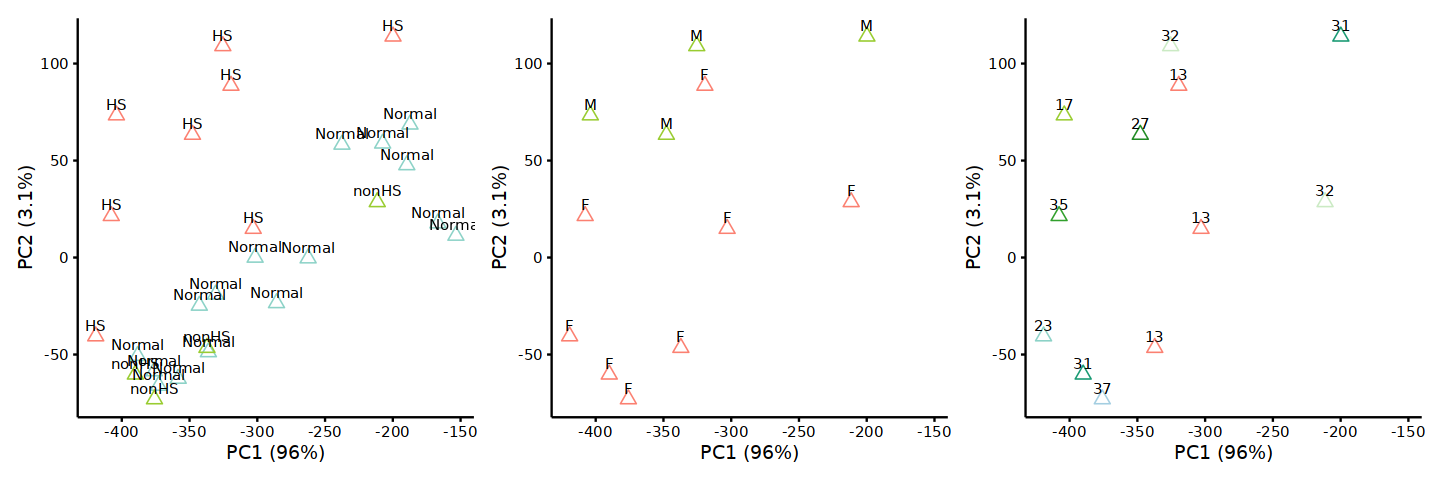

In [54]:
# Create the plot
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = disease, shape = disease)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$disease ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Create the plot
p2 = ggplot(pca_data, aes(x = PC1, y = PC2, color = sex, shape = sex)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black"),
    legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$sex ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')

# Create the plot
pca_data$age = as.character(pca_data$age)
p3 = ggplot(pca_data, aes(x = PC1, y = PC2, color = age, shape = age)) +
  geom_point(size = 3) +
  scale_color_manual(values = c(best_color)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black") #,legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = "")) +
  geom_text(aes(label = pca_data$age ), 
            vjust = -0.5, 
            hjust = 0.5, 
            size = 3, 
            color = "black")+theme(legend.position = 'none')
# Set plot dimensions
options(repr.plot.width = 12, repr.plot.height = 4)

# Display the plot
p1+p2+p3

In [55]:
pca_data$disease = factor(pca_data$disease,levels = c('HS','Normal','nonHS') )

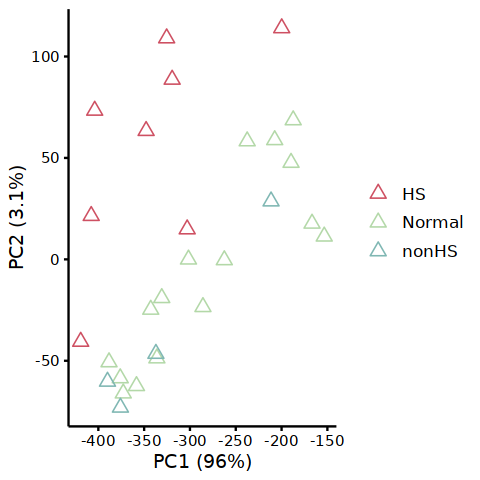

In [62]:
p1 = ggplot(pca_data, aes(x = PC1, y = PC2, color = disease, shape = disease)) +
  geom_point(size = 3) +
  scale_color_manual(values = rev(col2)) +
  scale_shape_manual(values = rep(2, 48)) +  # Specify shapes manually
  theme_classic() +
  theme(
    legend.text = element_text(color = "black", size = 10),
    panel.background = element_rect(fill = "white"),
    legend.background = element_blank(),
    legend.title = element_blank(),
    plot.background = element_rect(fill = "white"),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.title.x = element_text(color = "black"),
    axis.title.y = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    plot.title = element_text(color = "black", size = 10),
    axis.text = element_text(color = "black") #,legend.position = c(0.1, 0.9)
  ) +
  xlab(paste("PC1 (", round(summary(pca)$importance[2, 1] * 100, 1), "%)", sep = "")) +
  ylab(paste("PC2 (", round(summary(pca)$importance[2, 2] * 100, 1), "%)", sep = ""))
options(repr.plot.width = 4, repr.plot.height = 4)
p1


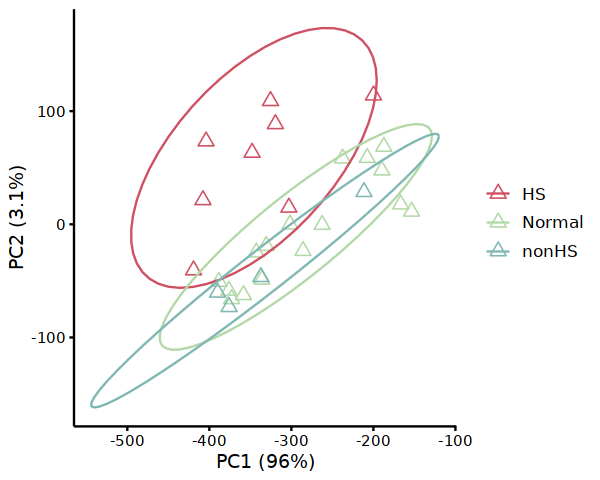

In [63]:
options(repr.plot.width = 5)
pp1 = p1+stat_ellipse(level = 0.9)
pp1

In [64]:
ggsave('ADcon_stereo.pca.pdf',pp1,width = 6,height = 5)
getwd()

[1] "/data/work/07.ReAnalysis/02.bin/02_10X_ADstereo"

## Fig1e-DEG数量热图

In [3]:
de = readRDS('/data/work/07.ReAnalysis/02.bin/01_Fig1/02.00.HS_vs_Normal.allArea.allgenes.250715.rds')

In [4]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
de$up.down = "No_Sig"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC>logFCfilter)] = "up"
de$up.down[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & de$avg_log2FC< -logFCfilter)] = "down"
df = de[which(de$up.down %in% c('up','down') ),]

In [ ]:
# df = df[-which(df$cluster %in% c('Blood','EX_CA2-4','EX_DG') ),]
# table(df$cluster,df$up.down)
deg_num = data.frame(table(df$cluster,df$up.down))
# deg_num
# 使用spread函数将gd1_long长数据转换为宽数据gd1_wide
deg_num <- tidyr::spread(deg_num,Var2,Freq) #year为需要分解的变量，gdp为分解后的列的取值
deg_num

row.names(deg_num) = deg_num$Var1
deg_num = deg_num[,-1]
deg_num$down = -deg_num$down

deg_num = deg_num[ c('CA1','CA2','CA3','CA4','DG','FAS','SLRM','Sub'),]
# deg_num = deg_num[order(-deg_num$up),]

library(circlize)# colorRamp2
library(ComplexHeatmap)
col_fun = circlize::colorRamp2(c(-1000, 0, 600),   c("#74B6ED","white","#D60029")) #c("#96C9F4","#FFAAAA", "#FF7777")
p = ComplexHeatmap::Heatmap(deg_num ,cluster_rows = F,cluster_columns = F,
            cell_fun = function(j, i, x, y, width, height, fill) { grid.text( abs(deg_num[i, j] ), x, y, gp = gpar(fontsize = 10))},
            width = ncol(deg_num)*unit(11, "mm"), height = nrow(deg_num)*unit(11, "mm"),## 方块cell大小
            col = col_fun , column_names_rot = 45)

pdf('DEGnum.pdf')
p
dev.off()
getwd()

## Fig1g,i-DEG占比饼图

In [25]:
de.all = read.table('03.area.DEG_class.txt',sep="\t",header=T,check.names=F)
de.all$class_merge = 'Specific'
de.all$class_merge[which(de.all$class == 'Neuron' )] = 'Neuron'
de.all$class_merge[which(de.all$class == 'Glial' )] = 'Glial'
de.all$class_merge[which(de.all$class == 'AllType' )] = 'Common'

de.all$class = factor(de.all$class,levels = c('AllType','Neuron','Glial','CA1_specific','CA2_specific','CA3_specific','CA4_specific','DG_specific','FAS_specific','SLRM_specific') )
de.all$class_merge = factor(de.all$class_merge,levels = c('Common','Neuron','Glial','Specific') )
de.all = de.all[order(de.all$class),]

table(de.all$up.down,de.all$class)

write.table(de.all,'03.02.up_down.DEG_class_merge.txt',sep="\t",quote=F,row.names=F)


      
       AllType Neuron Glial CA1_specific CA2_specific CA3_specific CA4_specific
  down     418    683     0          127          376          199           37
  up       387    173     1          156           11           72           56
      
       DG_specific FAS_specific SLRM_specific
  down          46           41             5
  up            55           19             8

In [26]:
library(ggiraphExtra)
up.df = de.all[which(de.all$up.down == 'up'),]
down.df = de.all[which(de.all$up.down == 'down'),]

pdf('03.02.up.DEG_class_merge.PieDonut.pdf')
ggPieDonut(data=up.df, aes(pies=class_merge) )
dev.off()

pdf('03.02.down.DEG_class_merge.PieDonut.pdf')
ggPieDonut(data=down.df, aes(pies=class_merge) )
dev.off()

png 
  2

png 
  2

In [ ]:
up.df = de.all[which(de.all$up.down == 'up'),]
down.df = de.all[which(de.all$up.down == 'down'),]

###type分类
library(ggiraphExtra)
ggPieDonut(data=up.df, aes(pies=class_merge) )
ggPieDonut(data=up.df, aes(donuts=class) )

ggPieDonut(data=down.df, aes(pies=class_merge) )
ggPieDonut(data=down.df, aes(donuts=class) )


pdf('03.02.up.DEG_class_merge.PieDonut.pdf')
ggPieDonut(data=up.df, aes(pies=class_merge) )
dev.off()


pdf('03.02.up.DEG_class.PieDonut.pdf')
ggPieDonut(data=up.df, aes(donuts=class) )
dev.off()


pdf('03.02.down.DEG_class_merge.PieDonut.pdf')
ggPieDonut(data=down.df, aes(pies=class_merge) )
dev.off()

pdf('03.02.down.DEG_class.PieDonut.pdf')
ggPieDonut(data=down.df, aes(donuts=class) )
dev.off()


## Fig1h-通路打分热图（上调

In [4]:
suppressMessages({
library(circlize)# colorRamp2
library(AUCell)
})

In [5]:
# seuobj = readRDS("/data/work/07.ReAnalysis/02.bin/bin100_12chips.merge.xy_adj.250715.rds")
# date()
# seuobj <- NormalizeData(seuobj) %>% FindVariableFeatures(nfeatures=3000) %>% ScaleData() 
# date()

[1] "Thu Jul 17 15:39:54 2025"

Centering and scaling data matrix



[1] "Thu Jul 17 16:09:22 2025"

In [5]:
# saveRDS(seuobj,'/data/work/07.ReAnalysis/02.bin/bin100_12chips.af_scale.xy_adj.250715.rds')
seuobj = readRDS('/data/work/07.ReAnalysis/02.bin/bin100_12chips.af_scale.xy_adj.250715.rds')

In [ ]:
options(warn=-1) 
ExprMat = GetAssayData(seuobj, slot = 'data')
  half <- round(ncol(ExprMat)/2)
  n1=round(half/2)
  n2=round(ncol(ExprMat)*0.75)
  ExprMat_1 <- ExprMat[,1:n1]
  ExprMat_2 <- ExprMat[,(n1+1):half]
  ExprMat_3 <- ExprMat[,(half+1):n2]
  ExprMat_4 <- ExprMat[,(n2+1):ncol(ExprMat)]
  cells_rankings_1 <- AUCell_buildRankings(ExprMat_1)
  cells_rankings_2 <- AUCell_buildRankings(ExprMat_2)
  cells_rankings_3 <- AUCell_buildRankings(ExprMat_3)
  cells_rankings_4 <- AUCell_buildRankings(ExprMat_4)
  cells_rankings <- AUCell::cbind(cells_rankings_1, cells_rankings_2,cells_rankings_3, cells_rankings_4)

Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



    min      1%      5%     10%     50%    100% 
   1.00  461.84  844.20  981.00 1801.00 8616.00 


Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



In [29]:
######### up
GO.combined = read.table("/data/work/07.ReAnalysis/02.bin/01_Fig1/03.03.forplt.DEG_class.HS_up.GOterm.filter.250716.txt",
                    sep="\t",check.names=F,header=T)#,stringsAsFactors = FALSE,quote = ""
GO.combined = GO.combined[which(GO.combined$ONTOLOGY =='BP'),]

GO.combined2 = GO.combined %>% group_by(cluster) %>% top_n(10,Count)
GO.combined1 = GO.combined[which(GO.combined$filter==1),]
GO.combined = rbind(GO.combined1,GO.combined2)
GO.combined$type = paste0(GO.combined$cluster,'_',GO.combined$Description)
GO.combined = GO.combined[!duplicated(GO.combined$type),]
head(GO.combined[which(GO.combined$cluster=='AllType'),],3)

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,cluster,filter,type
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<int>,<chr>
7,BP,GO:0042063,gliogenesis,28/325,310/18903,8.38e-13,3.28000e-09,2.47000e-09,ABCA2/ASCL1/ATP1B2/CCL2/CD9/CLU/CSF1R/DAAM2/DAG1/FGF2/GFAP/GPR37L1/ID4/IL1B/IL6ST/ITGB4/LGI4/LRP1/MBOAT7/MYRF/NTRK2/PAX6/PHGDH/PLEC/PLPP3/SOX2/SOX9/VIM,28,AllType,1,AllType_gliogenesis
27,BP,GO:0070371,ERK1 and ERK2 cascade,20/325,340/18903,1.95e-06,2.93888e-04,2.21082e-04,AGT/CCL2/CCL3L3/CCN2/CD44/CD74/CSF1R/CTSH/EZR/FGF1/FGF2/FGFR3/GNAI2/GSTP1/IL1B/JUN/NDRG2/NOTCH2/SOX9/ZFP36L1,20,AllType,1,AllType_ERK1 and ERK2 cascade
37,BP,GO:0030198,extracellular matrix organization,19/325,318/18903,2.82e-06,3.55299e-04,2.67279e-04,ABI3BP/ADAMTSL3/AEBP1/AGT/ANTXR1/ANXA2/CCDC80/CCN2/CST3/DAG1/GFAP/HAPLN2/LRP1/LTBP3/PBXIP1/PDPN/SFRP2/SMOC1/SOX9,19,AllType,1,AllType_extracellular matrix organization


In [30]:
######### up
GO.combined = read.table("/data/work/07.ReAnalysis/02.bin/01_Fig1/03.03.forplt.DEG_class.HS_up.GOterm.filter.250716.txt",
                    sep="\t",check.names=F,header=T)#,stringsAsFactors = FALSE,quote = ""
GO.combined = GO.combined[which(GO.combined$ONTOLOGY =='BP'),]

GO.combined2 = GO.combined %>% group_by(cluster) %>% top_n(10,Count)
GO.combined1 = GO.combined[which(GO.combined$filter==1),]
GO.combined = rbind(GO.combined1,GO.combined2)
GO.combined$type = paste0(GO.combined$cluster,'_',GO.combined$Description)
GO.combined = GO.combined[!duplicated(GO.combined$type),]

options(warn=-1) 
AUC.list=list()
for ( i in unique(GO.combined$type) ){
gene.list = unique(strsplit( GO.combined[which(GO.combined$type == i),'geneID'] ,split = "/") )
gene.list = unlist(gene.list)
length(gene.list)
    
gene.list = intersect(gene.list, row.names(cells_rankings) ) ###
cells_AUC <- AUCell_calcAUC(gene.list, cells_rankings, nCores = 16 )
AUC <- getAUC(cells_AUC)
AUC.list[[i]]=AUC
# print(i)
}

########## AUC得分合并&计算均值mean ##########
AUC.data=do.call(rbind,AUC.list)
dim(AUC.data)
rownames(AUC.data)=names(AUC.list)

[1]     98 202741

In [31]:
saveRDS(AUC.data,'04.00.bin_12chips.up.GOBP_AUCell.rds')

In [32]:
AUC.data[1:3,1:3]

,BIN100_279_1,BIN100_280_1,BIN100_281_1
AllType_gliogenesis,0.08908232,0.1069943,0.1940491
AllType_ERK1 and ERK2 cascade,0.21671782,0.0866763,0.1708792
AllType_extracellular matrix organization,0.07689531,0.1510165,0.1405282


In [33]:
meta=seuobj@meta.data
table(meta$group)

area=meta$area_m[match(colnames(AUC.data),rownames(meta))]
group=meta$group[match(colnames(AUC.data),rownames(meta))]
# head(group)
info.data=data.frame(area=area,group=group)
head(info.data)


result.list=list()
for (i in 1:nrow(AUC.data)) {
  info.data$expr=AUC.data[i,]
  result <- aggregate(expr ~ group + area , data = info.data, FUN = mean)
  result$term=rownames(AUC.data)[i]
  result.list[[i]]=result
}
result=do.call(rbind,result.list)

library(tidyr)
result$group_area=paste0(result$group,"_",result$area)

area.order = c('CA1','CA2','CA3','CA4','DG','FAS','SLRM')

########## AUC均值mean 变换格式##########
group_area.order = c()
for (i in area.order ){
group_area.order = c(group_area.order,paste0("Normal_",i) )
group_area.order = c(group_area.order ,paste0("HS_",i) )
}

###算group——area 表达
data_wide <- pivot_wider(result, id_cols = term, names_from = group_area, values_from = expr)

a=data_wide$term
data_wide=data_wide[,-1]
data_wide = data.frame(data_wide,check.names=F)
row.names(data_wide)=a

data_wide = data_wide[,group_area.order]

data_wide_t = t(data_wide)
# data_wide_t = scale(data_wide_t) 
data_wide_t = t(data_wide_t)



    HS Normal 
112248  90493 

,area,group
,<chr>,<chr>
1,CA1,Normal
2,CA1,Normal
3,CA1,Normal
4,CA1,Normal
5,CA1,Normal
6,CA1,Normal



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand




In [34]:
getwd()
saveRDS(data_wide_t,'04.01.bin_12chips.up.GOBP_AUCell.area_group_score_mean.rds')

[1] "/data/work/07.ReAnalysis/02.bin/01_Fig1"

In [ ]:
ls()

In [93]:
######### down
GO.combined = read.table("/data/work/07.ReAnalysis/02.bin/01_Fig1/03.03.forplt.DEG_class.HS_down.GOterm.filter.250716_forplt.txt",
                    sep="\t",check.names=F,header=T)#,stringsAsFactors = FALSE,quote = ""

GO.combined2 = GO.combined %>% group_by(cluster) %>% top_n(10,Count)
GO.combined1 = GO.combined[which(GO.combined$filter==1),]
GO.combined = rbind(GO.combined1,GO.combined2)
GO.combined$type = paste0(GO.combined$cluster,'_',GO.combined$Description)
GO.combined = GO.combined[!duplicated(GO.combined$type),]

GO.combined$type = paste0(GO.combined$cluster,'_',GO.combined$Description)

options(warn=-1) 
AUC.list=list()
for ( i in unique(GO.combined$type) ){
gene.list = unique(strsplit(GO.combined[which(GO.combined$type == i),'geneID'] ,split = "/") )
gene.list = unlist(gene.list)
length(gene.list)
    
gene.list = intersect(gene.list, row.names(cells_rankings) ) ###
cells_AUC <- AUCell_calcAUC(gene.list, cells_rankings, nCores = 16 )
AUC <- getAUC(cells_AUC)
AUC.list[[i]]=AUC
# print(i)
}
########## AUC得分合并&计算均值mean ##########
AUC.data=do.call(rbind,AUC.list)
dim(AUC.data)
rownames(AUC.data)=names(AUC.list)

saveRDS(AUC.data,'04.00.bin_12chips.down.GOBP_AUCell.rds')

[1]    103 202741

In [94]:
date()

[1] "Thu Jul 17 22:57:35 2025"

In [95]:
meta=seuobj@meta.data

area=meta$area_m[match(colnames(AUC.data),rownames(meta))]
group=meta$group[match(colnames(AUC.data),rownames(meta))]
# head(group)
info.data=data.frame(area=area,group=group)
head(info.data)


result.list=list()
for (i in 1:nrow(AUC.data)) {
  info.data$expr=AUC.data[i,]
  result <- aggregate(expr ~ group + area , data = info.data, FUN = mean)
  result$term=rownames(AUC.data)[i]
  result.list[[i]]=result
}
result=do.call(rbind,result.list)

library(tidyr)
result$group_area=paste0(result$group,"_",result$area)

area.order = c('CA1','CA2','CA3','CA4','DG','FAS','SLRM')

########## AUC均值mean 变换格式##########
group_area.order = c()
for (i in area.order ){
group_area.order = c(group_area.order,paste0("Normal_",i) )
group_area.order = c(group_area.order ,paste0("HS_",i) )
}

###算group——area 表达
data_wide <- pivot_wider(result, id_cols = term, names_from = group_area, values_from = expr)

a=data_wide$term
data_wide=data_wide[,-1]
data_wide = data.frame(data_wide,check.names=F)
row.names(data_wide)=a

data_wide = data_wide[,group_area.order]

data_wide_t = t(data_wide)
# data_wide_t = scale(data_wide_t) 
data_wide_t = t(data_wide_t)
data_wide_t[1:2,1:3]

getwd()
saveRDS(data_wide_t,'04.01.bin_12chips.down.GOBP_AUCell.area_group_score_mean.rds')

,area,group
,<chr>,<chr>
1,CA1,Normal
2,CA1,Normal
3,CA1,Normal
4,CA1,Normal
5,CA1,Normal
6,CA1,Normal


,Normal_CA1,HS_CA1,Normal_CA2
AllType_modulation of chemical synaptic transmission,0.4566367,0.3095854,0.5051492
AllType_synapse organization,0.4183636,0.2797865,0.4706485


[1] "/data/work/07.ReAnalysis/02.bin/01_Fig1"

In [ ]:
data_wide_t = readRDS('/data/work/07.ReAnalysis/02.bin/01_Fig1/04.01.bin_12chips.up.GOBP_AUCell.area_group_score_mean.rds')

go = read.table("/data/work/07.ReAnalysis/02.bin/01_Fig1/03.03.DEG_class.HS_up.GOterm.filter.250716.txt",
                    sep="\t",check.names=F,header=T)#,stringsAsFactors = FALSE,quote = ""
go = go[which(go$ONTOLOGY =='BP'),]

# go = go[which(go$filter==1),]
# go = go[-which(go$cluster=='Neuron'),]

go$type = paste0(go$cluster,'_',go$Description)
dim(go)

In [18]:
area.order = c('CA1','CA2','CA3','CA4','DG','FAS','SLRM')
### 相减
data_Con_disease = data.frame(matrix(NA,ncol = length(area.order) ,nrow = dim(data_wide_t)[1] ))

for (i in 1:length(area.order)){
data_Con_disease[,i] = data_wide_t[,colnames(data_wide_t)[2*i] ] - data_wide_t[,colnames(data_wide_t)[2*i-1] ] #癫痫-Con
    # print(colnames(data_wide_t)[2*i] )
    # print(colnames(data_wide_t)[2*i-1] )
}

colnames(data_Con_disease) = area.order
row.names(data_Con_disease) = row.names(data_wide_t)

data_Con_disease = data_Con_disease[intersect(go$type,row.names(data_Con_disease)) ,]
dim(data_Con_disease)
data_Con_disease[1,]

[1] 9 7

,CA1,CA2,CA3,CA4,DG,FAS,SLRM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AllType_gliogenesis,0.1007756,0.09994822,0.1036743,0.06795061,0.06845905,0.0640446,0.0645206


,type,go
,<chr>,<chr>
1,AllType,AllType_gliogenesis
2,AllType,AllType_ERK1 and ERK2 cascade
3,AllType,AllType_regulation of I-kappaB kinase/NF-kappaB signaling


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


png 
  2

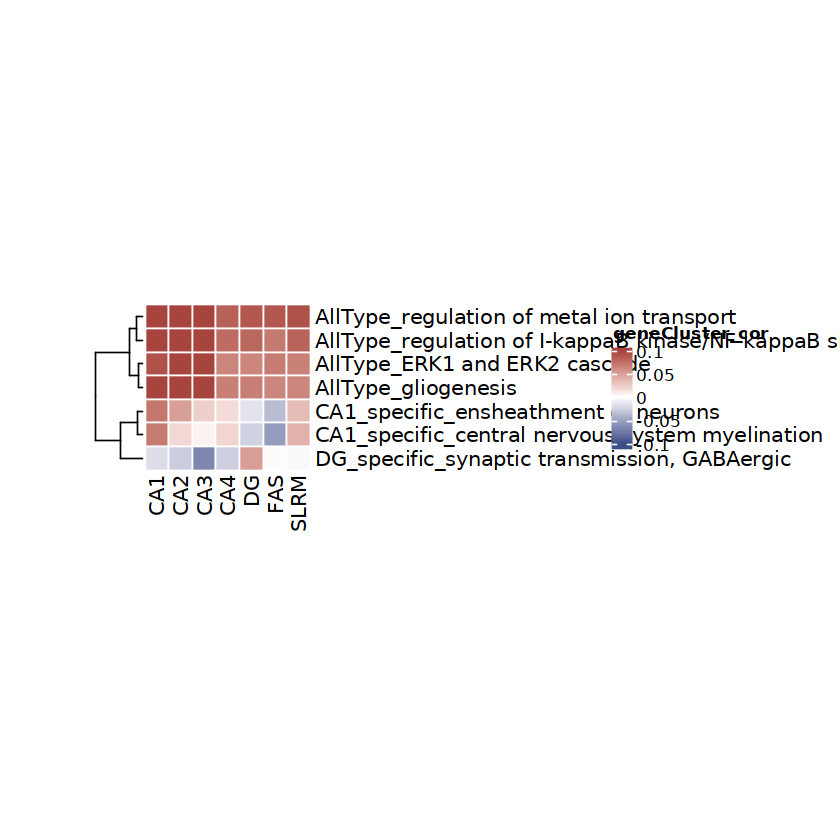

In [48]:

data_Con_disease = data_Con_disease[intersect(go$type,row.names(data_Con_disease)) ,]

###行名注释
row.define = data.frame(matrix(NA,ncol = 2,nrow = length(row.names(data_Con_disease)) ))
colnames(row.define) = c('type','go')
row.define$go = row.names(data_Con_disease)
row.define$type = go$cluster[match(row.define$go,go$type)]
# row.define$area = gsub("_.*$","",row.names(data_Con_disease))
row.define[1:3,]

##排序
row.define = row.define[order(row.define$type),]

gene_mean_df = data_Con_disease
gene_mean_df = gene_mean_df[row.define$go,]#行 排序
#排序
row.type = data.frame(row.define$type)
row.names(row.type) = row.define$go

col_fun = circlize::colorRamp2(c(-0.1, 0, 0.1),  c("#3C5088","white","#A6443D"))
################################
p = Heatmap(gene_mean_df ,cluster_rows = T,cluster_columns = F,
          # left_annotation = left_anno,
            name = "geneCluster_cor", row_split = row.define.up ,
           rect_gp = gpar(col = "white",lwd = 1), ## 设置边框颜色
            width = ncol(gene_mean_df)*unit(5, "mm"), height = nrow(gene_mean_df)*unit(5, "mm"),## 方块cell大小
            col = col_fun )
p
#c("#5B68B5","white","#AC2C2C")
pdf('Fig1d.GOup.AUCell.pdf',height = 20)
p
dev.off()

## Fig1j-通路打分热图（下调

In [49]:
data_wide_t = readRDS('/data/work/07.ReAnalysis/02.bin/01_Fig1/04.01.bin_12chips.down.GOBP_AUCell.area_group_score_mean.rds')
go = read.table("/data/work/07.ReAnalysis/02.bin/01_Fig1/03.03.forplt.DEG_class.HS_down.GOterm.filter.250716_forplt.txt",
                    sep="\t",check.names=F,header=T)#,stringsAsFactors = FALSE,quote = ""
# go = go[which(go$filter==1),]
# go = go[-which(go$cluster=='Neuron'),]

go$type = paste0(go$cluster,'_',go$Description)
dim(go)

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“EOF within quoted string”
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”


[1] 1647   13

In [51]:
need = c('AllType_modulation of chemical synaptic transmission','AllType_calcium ion transport',
  'Neuron_ATP metabolic process','Neuron_synapse organization',
  # 'Neuron_ribonucleotide metabolic process',
  # 'CA1_specific_regulation of membrane potential',
  'CA1_specific_regulation of nervous system development','CA1_specific_regulation of neuron projection development')
go = go[which(go$type %in% need),]
dim(go)

[1]  6 13

In [52]:
area.order = c('CA1','CA2','CA3','CA4','DG','FAS','SLRM')
### 相减
data_Con_disease = data.frame(matrix(NA,ncol = length(area.order) ,nrow = dim(data_wide_t)[1] ))

for (i in 1:length(area.order)){
data_Con_disease[,i] = data_wide_t[,colnames(data_wide_t)[2*i] ] - data_wide_t[,colnames(data_wide_t)[2*i-1] ] #癫痫-Con
    # print(colnames(data_wide_t)[2*i] )
    # print(colnames(data_wide_t)[2*i-1] )
}

colnames(data_Con_disease) = area.order
row.names(data_Con_disease) = row.names(data_wide_t)

data_Con_disease[1,]

,CA1,CA2,CA3,CA4,DG,FAS,SLRM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AllType_modulation of chemical synaptic transmission,-0.1470513,-0.1561203,-0.2369168,-0.1814735,-0.07326251,-0.05645716,-0.09090039


[1] 6 7

,type,go
,<chr>,<chr>
1,AllType,AllType_modulation of chemical synaptic transmission
2,AllType,AllType_calcium ion transport
3,Neuron,Neuron_synapse organization


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


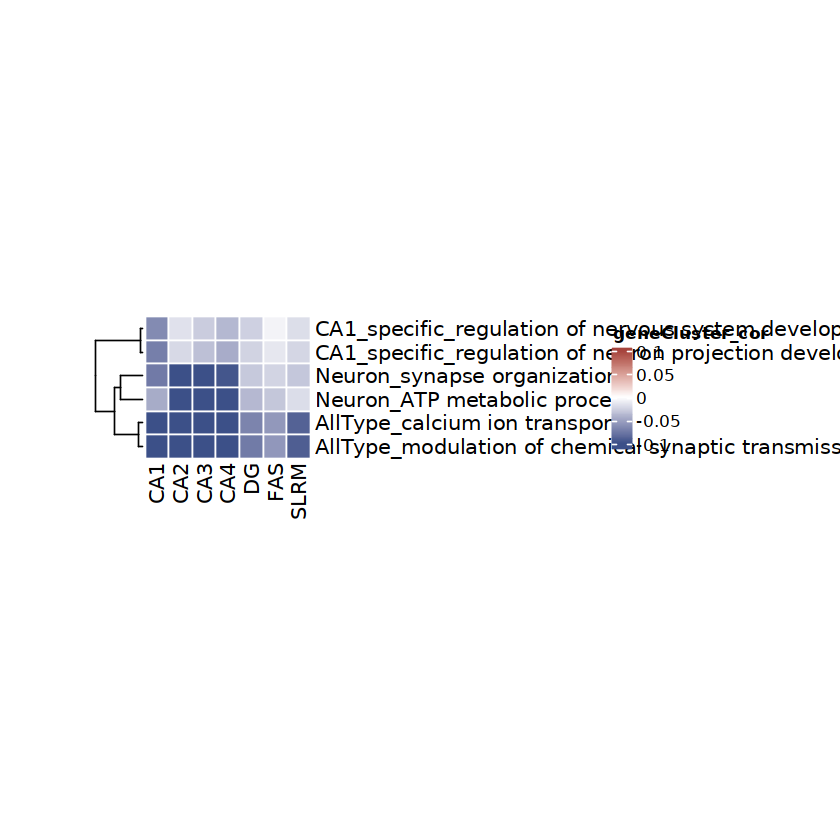

In [53]:

data_Con_disease = data_Con_disease[intersect(go$type,row.names(data_Con_disease)) ,]
dim(data_Con_disease)
###行名注释
row.define = data.frame(matrix(NA,ncol = 2,nrow = length(row.names(data_Con_disease)) ))
colnames(row.define) = c('type','go')
row.define$go = row.names(data_Con_disease)
row.define$type = go$cluster[match(row.define$go,go$type)]
# row.define$area = gsub("_.*$","",row.names(data_Con_disease))
row.define[1:3,]

##排序
row.define = row.define[order(row.define$type),]
# gene_mean_df = data_Con_disease

gene_mean_df = data_Con_disease
# gene_mean_df = gene_mean_df[row.names(annotation_row),]#annotation_row
gene_mean_df = gene_mean_df[row.define$go,]#行 排序
#排序

row.type = data.frame(row.define$type)
row.names(row.type) = row.define$go

col_fun = circlize::colorRamp2(c(-0.1, 0, 0.1),  c("#3C5088","white","#A6443D"))

################################
p = Heatmap(gene_mean_df ,cluster_rows = T,cluster_columns = F,
          # left_annotation = left_anno,
            name = "geneCluster_cor", 
           rect_gp = gpar(col = "white",lwd = 1), ## 设置边框颜色
            width = ncol(gene_mean_df)*unit(5, "mm"), height = nrow(gene_mean_df)*unit(5, "mm"),## 方块cell大小
            col = col_fun )
p
#c("#5B68B5","white","#AC2C2C")


In [54]:
pdf('Fig1d.GOdown.AUCell.pdf',height = 40)
p
dev.off()

png 
  2

## Fig1k-通路打分后空间中展示

In [ ]:
for(i in need ){
gliogenesis_scores <- as.numeric(score[i, ])
    name = gsub(' ','',i)
name = gsub('/','',name)
# 确保列名和行名顺序一致
names(gliogenesis_scores) <- colnames(score)
# 将分数添加到seuobj的metadata中
seuobj@meta.data$scores <- gliogenesis_scores[rownames(seuobj@meta.data)]

coord <- data.frame(stereo_1 = seuobj$coor_x, stereo_2 = seuobj$coor_y)
seuobj[["stereo"]] <- SeuratObject::CreateDimReducObject(embeddings = as.matrix(coord), key = "stereo_", assay = "RNA")

hs34 = subset(seuobj,sample == 'HS34' )
hs43 = subset(seuobj,sample == 'HS43')

lines = readRDS('/data/work/07.ReAnalysis/02.bin/bin100_12chips.xy_adj.250715.line.rds')
lines$coor_x = lines$rx
lines$coor_y = lines$ry

hs34_line = lines[which(lines$sample=='HS34'),]
hs43_line = lines[which(lines$sample=='HS43'),]

    
    p1 = FeaturePlot( hs34 , features = 'scores' ,reduction = "stereo",pt.size = 0.3)+
    scale_colour_gradientn(colors = colorRampPalette(c("#3C5088", "white", "#A6443D"))(100),limits = c(0, 0.6) ) +
            # DarkTheme()+
            labs(subtitle  = i)+
            theme(axis.line = element_blank(), axis.text = element_blank(), axis.ticks = element_blank(), axis.title = element_blank())+coord_fixed()+
            geom_point(data = hs34_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
    
    p2 = FeaturePlot( hs43 , features = 'scores' ,reduction = "stereo",pt.size = 0.1)+
    scale_colour_gradientn(colors = colorRampPalette(c("#3C5088", "white", "#A6443D"))(100),limits = c(0, 0.6) ) +
            # DarkTheme()+
            labs(subtitle  = i)+
            theme(axis.line = element_blank(), axis.text = element_blank(), axis.ticks = element_blank(), axis.title = element_blank())+coord_fixed()+
            geom_point(data = hs43_line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

ggsave(paste0('/data/work/07.ReAnalysis/02.bin/01_Fig1/GO_spatial/Fig2g.spatial.HS34.',name,'.pdf'),p1,width = 8,height = 6)
ggsave(paste0('/data/work/07.ReAnalysis/02.bin/01_Fig1/GO_spatial/Fig2g.spatial.HS43.',name,'.pdf'),p2,width = 7,height = 5)
}

In [ ]:
p1 = ggplot(hs34@meta.data, aes(as.numeric(coor_x), as.numeric(coor_y), fill = AllType_NFkappaB)) + 
  geom_tile() + 
  theme_classic() +
  scale_fill_gradientn(
    colors = colorRampPalette(c("#3C5088", "white", "#A6443D"))(50),
    limits = c(0, 0.6),
    name = "Gliogenesis Score"
  ) +
  # 叠加图层：黑点（禁用继承映射）
  geom_point(
    data = hs34_line, 
    aes(x = coor_x, y = coor_y), 
    size = 0.000001,  # 调整为可见大小（仅示例）
    color = "black",
    inherit.aes = FALSE
  )

options(repr.plot.width = 5,repr.plot.height = 4)
p1